In [21]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent
prices = pd.read_csv(ROOT / "data" / "clean_data.csv")
signals = pd.read_csv(ROOT / "data" / "signals_strategy_1.csv")

In [22]:
df = prices.merge(
    signals,
    on="Date",
    how="inner"
)
print(df.head())

         Date        Close         High          Low         Open  Volume  \
0  2010-02-02  4830.100098  4951.149902  4814.100098  4907.850098       0   
1  2010-02-03  4931.850098  4949.149902  4831.000000  4831.000000       0   
2  2010-02-04  4845.350098  4931.299805  4832.350098  4931.299805       0   
3  2010-02-05  4718.649902  4827.000000  4692.350098  4819.649902       0   
4  2010-02-08  4760.399902  4799.049805  4675.399902  4755.350098       0   

        State_0   State_1        State_2       State_3       State_4  \
0  0.000000e+00  1.000000  1.253288e-182  1.053696e-84  1.654023e-81   
1  1.061187e-26  0.792113   6.957536e-10  1.490111e-03  2.063971e-01   
2  5.576504e-28  0.533838   1.158662e-11  3.841877e-04  4.657776e-01   
3  2.656135e-41  0.015467   8.278132e-20  2.678238e-03  9.818546e-01   
4  5.407933e-42  0.000157   3.276641e-21  1.215314e-04  9.997216e-01   

        State_5  Target_Position    Trade_Size  
0  0.000000e+00     1.654023e-81  1.654023e-81  
1  4.4

In [23]:
df["Return"] = df["Close"].pct_change()

print(df[["Date","Close","Return"]].head(10))

         Date        Close    Return
0  2010-02-02  4830.100098       NaN
1  2010-02-03  4931.850098  0.021066
2  2010-02-04  4845.350098 -0.017539
3  2010-02-05  4718.649902 -0.026149
4  2010-02-08  4760.399902  0.008848
5  2010-02-09  4792.649902  0.006775
6  2010-02-10  4757.200195 -0.007397
7  2010-02-11  4826.850098  0.014641
8  2010-02-15  4801.950195 -0.005159
9  2010-02-16  4855.750000  0.011204


In [24]:
df["Strategy_Return"] = (
    df["Target_Position"].shift(1)
    * df["Return"]
)

df["Strategy_Return"] = (
    df["Strategy_Return"]
    .fillna(0)
)

print(df[["Date","Return","Target_Position","Strategy_Return"]].head(10))

         Date    Return  Target_Position  Strategy_Return
0  2010-02-02       NaN     1.654023e-81     0.000000e+00
1  2010-02-03  0.021066     2.063971e-01     3.484335e-83
2  2010-02-04 -0.017539     4.657776e-01    -3.620010e-03
3  2010-02-05 -0.026149     9.818546e-01    -1.217954e-02
4  2010-02-08  0.008848     9.997216e-01     8.687321e-03
5  2010-02-09  0.006775     9.999813e-01     6.772755e-03
6  2010-02-10 -0.007397     9.999845e-01    -7.396543e-03
7  2010-02-11  0.014641     9.999964e-01     1.464072e-02
8  2010-02-15 -0.005159     9.999954e-01    -5.158605e-03
9  2010-02-16  0.011204     9.999974e-01     1.120369e-02


In [25]:
df["Equity"] = (
    1 + df["Strategy_Return"]
).cumprod()

print(
    df[["Date","Equity"]]
    .head(10)
)

         Date    Equity
0  2010-02-02  1.000000
1  2010-02-03  1.000000
2  2010-02-04  0.996380
3  2010-02-05  0.984245
4  2010-02-08  0.992795
5  2010-02-09  0.999519
6  2010-02-10  0.992126
7  2010-02-11  1.006651
8  2010-02-15  1.001458
9  2010-02-16  1.012679


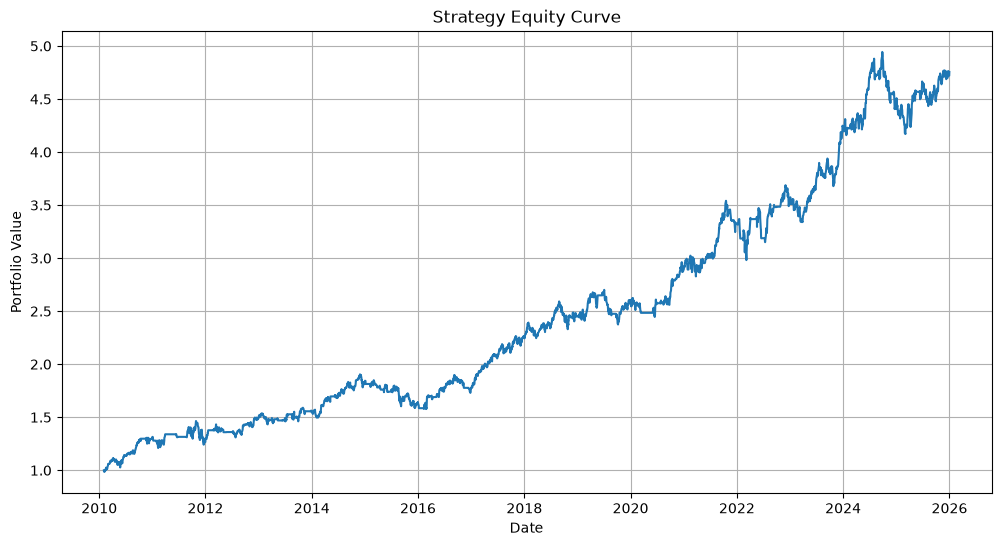

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df["Date"] = pd.to_datetime(df["Date"])

plt.plot(
    df["Date"],
    df["Equity"]
)

plt.title("Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [27]:
years = (
    (df["Date"].iloc[-1] - df["Date"].iloc[0])
    .days
    / 365.25
)

final_equity = df["Equity"].iloc[-1]

cagr = (
    final_equity ** (1 / years)
    - 1
)

print(f"CAGR: {cagr:.2%}")

CAGR: 10.30%


In [28]:
sharpe = (
    df["Strategy_Return"].mean()
    /
    df["Strategy_Return"].std()
) * (252 ** 0.5)

print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: 0.95


In [29]:
df["Rolling_Max"] = (
    df["Equity"]
    .cummax()
)

df["Drawdown"] = (
    df["Equity"]
    /
    df["Rolling_Max"]
    - 1
)

max_drawdown = (
    df["Drawdown"]
    .min()
)

print(
    f"Max Drawdown: {max_drawdown:.2%}"
)

Max Drawdown: -17.18%


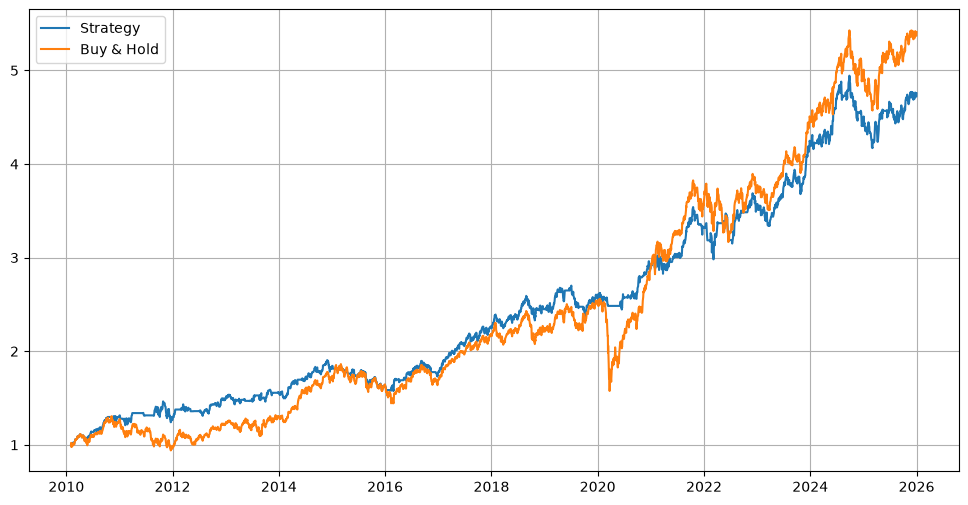

In [30]:
df["Market_Equity"] = (
    1 + df["Return"].fillna(0)
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Equity"], label="Strategy")
plt.plot(df["Date"], df["Market_Equity"], label="Buy & Hold")

plt.legend()
plt.grid(True)
plt.show()